In [1]:
import torch
import torchaudio

In [5]:
from timbre_trap.timbre_trap.framework import TimbreTrap

In [6]:
tt = TimbreTrap(sample_rate=22050,
                n_octaves=9,
                bins_per_octave=60,
                secs_per_block=3,
                latent_size=128,
                model_complexity=2,
                skip_connections=False)

In [7]:
tt.load_state_dict(torch.load('checkpoints/tt-orig.pt'))

<All keys matched successfully>

In [79]:
y, sr = torchaudio.load('tests/extracts/Fu/A_1218.779_Ring.wav')
y = y.to('cuda')

In [15]:
y[1, :].unsqueeze(0).unsqueeze(0).shape

torch.Size([1, 1, 84716])

In [41]:
tt.to('cuda')
reconstruction, latents, transcription, transcription_rec, transcription_scr, losses = tt(y[1, :66150].unsqueeze(0).unsqueeze(0))

In [65]:
tt.sliCQ.get_expected_frames(66150)

1024

In [66]:
tt.sliCQ.hop_length

64.599609375

In [37]:
reconstruction.shape

torch.Size([1, 2, 540, 1024])

In [43]:
transcription.shape

torch.Size([1, 2, 540, 1024])

In [56]:
activations = tt.transcribe(y[1, :].unsqueeze(0).unsqueeze(0))

		processing chunks:   0%|          | 0/5 [00:00<?, ?it/s]

		processing chunks: 100%|██████████| 5/5 [00:00<00:00, 179.12it/s]


In [58]:
activations.shape

torch.Size([1, 540, 2048])

In [88]:
cqt = tt.sliCQ.to_magnitude(tt.sliCQ.encode((y[1, :66150].unsqueeze(0).unsqueeze(0))))

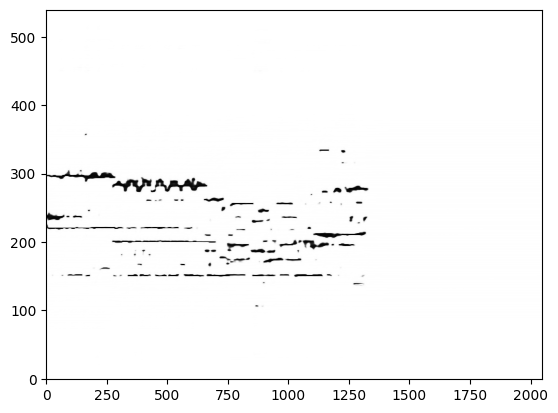

In [59]:
import matplotlib.pyplot as plt

plt.imshow(activations[0, :, :].detach().cpu().numpy(), origin='lower', aspect='auto', cmap='Greys')

In [90]:
cqt.shape

torch.Size([1, 540, 1024])

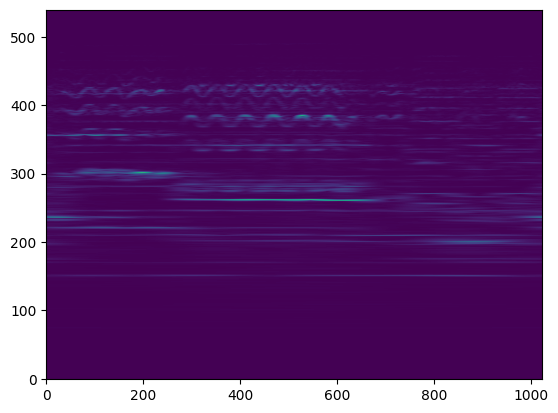

In [91]:
plt.imshow(cqt[0, :, :].detach().cpu().numpy(), origin='lower', aspect='auto')

In [26]:
transcription.shape

torch.Size([1, 2, 540, 1024])